<a href="https://colab.research.google.com/github/Juni0rResearcher/AdvancedRobotics/blob/main/HW3_EulerEKFvsQuaternionEKF/HW3_EulerEKFvsQuaternionEKF_Iuzhanin_Andrei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home assignment 3. Euler-based EKF vs Quaternion-based EKF

**Студент:** Южанин Андрей

**Датасет:** https://drive.google.com/file/d/1Bc06cXcRaeMeUty0rxXAXAJC-2PoT04g/view?usp=share_link

**Задача:** Реализовать и сравнить два подхода к Extended Kalman Filter (EKF) для оценки ориентации смартфона: на углах Эйлера и на кватернионах.

**Данные:** Записанный единый лог данных (акселерометр + гироскоп) с датчиков смартфона.
 Протокол записи:
- Положите телефон на стол неподвижно на 5–10 секунд (калибровка).
- Плавно вращайте телефон в руках по всем трем осям.
- Критический тест: Поверните телефон так, чтобы ось Pitch (тангаж) достигла 90 градусов (вертикально). Это проверка на Gimbal Lock.
- Верните телефон в исходное положение.
- Экспортируйте CSV (акселерометр в м/с², гироскоп в рад/с).

**Реализация в Jupyter/Colab:**
1. Вам необходимо реализовать два фильтра, которые обрабатывают один и тот же набор данных:
    - Вариант А: Euler-based EKF (Углы Эйлера)
    - Вариант Б: Quaternion-based EKF (Кватернионы)
2. Анализ и Визуализация. В ipynb-файле должны присутствовать следующие графики:
    - Графики углов: Постройте Roll, Pitch, Yaw для обоих методов на одном графике (для варианта Б переведите кватернионы в углы Эйлера для наглядности сравнения).
    - Анализ нормы: Для варианта Б постройте график нормы кватерниона перед этапом нормализации. Это покажет, как накапливается вычислительная ошибка.
3. Результат: Загрузите ваши CSV- и ipynb- файлы в Github

## 1. Установка и импорт библиотек

In [ ]:
!pip install gdown -q

In [ ]:
import numpy as np
import pandas as pd
import gdown
import math
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import warnings

Подключение Google Drive

In [ ]:
url = 'https://drive.google.com/file/d/1Bc06cXcRaeMeUty0rxXAXAJC-2PoT04g/view?usp=share_link'

file_id = url.split('/d/')[1].split('/')[0]
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(direct_url)
print(df.head())

                       time      ax      ay      az      wx      wy      wz
0  2026-03-11T13:55:56.911Z  0.0849  0.0033  0.2322 -0.0095 -0.0065  0.0029
1  2026-03-11T13:55:56.920Z -0.0366  0.0440 -0.4784 -0.0050 -0.0179  0.0033
2  2026-03-11T13:55:56.930Z  0.0579  0.0131  0.1098  0.0014  0.0159  0.0034
3  2026-03-11T13:55:56.940Z  0.0015  0.0235 -0.2318 -0.0110 -0.0227  0.0037
4  2026-03-11T13:55:56.950Z  0.0145  0.0135 -0.1519  0.0020  0.0107  0.0034


In [ ]:
# Анализ данных
print("АНАЛИЗ ДАННЫХ")
print(f"\nСырые данные акселерометра:")
print(f"  ax: min={df['ax'].min():.4f}, max={df['ax'].max():.4f}, mean={df['ax'].mean():.4f}")
print(f"  ay: min={df['ay'].min():.4f}, max={df['ay'].max():.4f}, mean={df['ay'].mean():.4f}")
print(f"  az: min={df['az'].min():.4f}, max={df['az'].max():.4f}, mean={df['az'].mean():.4f}")

# Проверим первые несколько строк
print("\nПервые 5 строк данных:")
for i in range(5):
    print(f"  {i}: ax={df['ax'].iloc[i]:.4f}, ay={df['ay'].iloc[i]:.4f}, az={df['az'].iloc[i]:.4f}")

# Если данные в g, то норма должна быть около 1
norms = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
print(f"\nНорма акселерометра: min={norms.min():.3f}, max={norms.max():.3f}, mean={norms.mean():.3f}")

АНАЛИЗ ДАННЫХ

Сырые данные акселерометра:
  ax: min=-3.3058, max=4.6743, mean=-0.0346
  ay: min=-2.8203, max=2.9237, mean=-0.0798
  az: min=-4.9773, max=4.8903, mean=-0.1129

Первые 5 строк данных:
  0: ax=0.0849, ay=0.0033, az=0.2322
  1: ax=-0.0366, ay=0.0440, az=-0.4784
  2: ax=0.0579, ay=0.0131, az=0.1098
  3: ax=0.0015, ay=0.0235, az=-0.2318
  4: ax=0.0145, ay=0.0135, az=-0.1519

Норма акселерометра: min=0.050, max=5.355, mean=0.785


## 2. Вспомогательные функции

### 2.1 Исследование шума в данных

Исследуем шум в данных. Реализуем функцию для автоматической оценки параметров шума датчиков по реальным данным.

Фильтр Калмана требует знания ковариационных матриц шума:

- Q - шум процесса (как быстро накапливается ошибка гироскопа)
- R - шум измерения (насколько шумный акселерометр)

Если эти параметры задать неправильно, фильтр будет работать плохо:

- слишком маленький R приведет к тому, что фильтр будет доверять шумным измерениям;
- слишком большой R повлияет нато, что фильтр будет игнорировать измерения и дрейфовать;
- неправильный Q, следовательно, неверная оценка скорости накопления ошибки.

Функция решает эту проблему, оценивая шумы непосредственно из данных, когда объект неподвижен.

In [ ]:
def estimate_noise_from_static_data(df, static_duration_sec=5):
    """
    Оценка шума по данным, когда робот НЕ движется
    """
    # Вычисляем dt
    df_copy = df.copy()
    if 'time' in df_copy.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_copy['time']):
            df_copy['time'] = pd.to_datetime(df_copy['time'])
        df_copy['dt'] = df_copy['time'].diff().dt.total_seconds().fillna(0.01)
    else:
        df_copy['dt'] = 0.01

    # Берём первые N секунд статики
    dt_mean = df_copy['dt'].iloc[1:].mean()  # пропускаем первую строку с NaN
    n_samples = min(int(static_duration_sec / dt_mean), len(df_copy) // 2)
    static_data = df_copy.iloc[:n_samples]

    # Оценка шума акселерометра
    ax_var = static_data['ax'].var()
    ay_var = static_data['ay'].var()
    az_var = static_data['az'].var()
    R_est = np.diag([ax_var, ay_var, az_var])

    # Оценка шума гироскопа
    wx_var = static_data['wx'].var()
    wy_var = static_data['wy'].var()
    wz_var = static_data['wz'].var()

    # Шум процесса зависит от dt
    Q_est = np.diag([wx_var, wy_var, wz_var]) * dt_mean

    print(f"Оценка по статическим данным ({static_duration_sec}с, {n_samples} отсчетов):")
    print(f"   Средний dt: {dt_mean:.6f} с")
    print(f"   R (accel): [{ax_var:.6f}, {ay_var:.6f}, {az_var:.6f}]")
    print(f"   Q (gyro): [{wx_var*dt_mean:.6f}, {wy_var*dt_mean:.6f}, {wz_var*dt_mean:.6f}]")

    return Q_est, R_est

### 2.2 Функции преобразований для матриц поворота и углов Эйлера

Напишем вспомогательные функции:
 - `euler_to_rotation()` - Для преобращования углов Эйлера в матрицу поворота 3x3.
 - `rotation_matrix_to_euler(R_mat)` - Обратное преобразование - из матрицы поворота в углы Эйлера
 - `quat_normalize(q)` - Нормализует кватернион до единичной длины
 - `quat_multiply(q1, q2)` - Умножает два кватерниона (композиция вращений)
 - `quat_to_euler(q, degrees=False)` - Преобразует кватернион в углы Эйлера
 - `euler_to_quat(roll, pitch, yaw)` - Преобразует углы Эйлера в кватернион
 - `_gravity_vector_in_body(self, roll, pitch)` - Предсказывает показания акселерометра при заданных углах

In [ ]:
def euler_to_rotation(roll, pitch, yaw):
    return R.from_euler('zyx', [yaw, pitch, roll]).as_matrix()

def rotation_matrix_to_euler(R_mat):
    """Обратное преобразование"""
    return R.from_matrix(R_mat).as_euler('zyx', degrees=False)[[2,1,0]]  # [roll, pitch, yaw]

def quat_normalize(q):
    """Нормализация кватерниона"""
    return q / np.linalg.norm(q)

def quat_multiply(q1, q2):
    """Произведение кватернионов: q = q1 ⊗ q2"""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_to_euler(q, degrees=False):
    """
    Преобразование кватерниона [w,x,y,z] в углы Эйлера [roll, pitch, yaw]
    """

    r = R.from_quat([q[1], q[2], q[3], q[0]])

    # Получаем углы в порядке yaw, pitch, roll (ZYX)
    yaw, pitch, roll = r.as_euler('zyx', degrees=degrees)

    # Возвращаем в порядке roll, pitch, yaw
    return np.array([roll, pitch, yaw])

def euler_to_quat(roll, pitch, yaw):
    """Преобразование углов [roll, pitch, yaw] в кватернион [w,x,y,z]"""
    r = R.from_euler('zyx', [yaw, pitch, roll])
    quat = r.as_quat()  # [x, y, z, w]
    return np.array([quat[3], quat[0], quat[1], quat[2]])

def _gravity_vector_in_body(self, roll, pitch):
    # Гравитация в мировой системе направлена ВНИЗ
    g_world = np.array([0, 0, -1])  # ИСПРАВЛЕНО: минус!

    # Матрица вращения из тела в мир
    rot_mat = R.from_euler('zyx', [0, pitch, roll]).as_matrix()

    # Гравитация в системе тела = R^T * g_world
    g_body = rot_mat.T @ g_world

    return g_body

###2.3. Реализация Euler-based EKF

Реализуем класс `EulerEKF` - фильтр Калмана с состоянием в углах Эйлера.

1. В конструктуре инициализируем параметры, необходимые для работы фильтра:
    - `self.x` - вектор состояния **[roll, pitch, yaw]** в радианах
    - `self.P` - ковариационная матрица 3x3 (неопределенность оценки)
    - `self.Q` - ковариация шума процесса (ошибки гироскопа)
    - `self.R` - ковариация шума измерения (ошибки акселерометра)

    Напишем метод, `_gravity_vector_in_body` который предсказывает, что должен показывать акселерометр при текущей ориентации объекта (робота). Математическая модель:
    - В мировой системе гравитация всегда направлена вниз [0, 0, -1].
    - Если объект повернут, акселерометр видит проекцию этого вектора.
    - rot_mat.T @ g_world - преобразует вектор из мира в систему тела.

2. Используем функцию `predict` для связывания угловых скоростей с производными углов:
    - `roll_dot` - скорость изменения крена;

      `wx + wy·sin(roll)·tan(pitch) + wz·cos(roll)·tan(pitch)`
    - `pitch_dot` - скорость изменения тангажа

      `wy·cos(roll) - wz·sin(roll)`;
    - `yaw_dot` - скорость изменения рысканья

      `(wy·sin(roll) + wz·cos(roll))/cos(pitch)`

    Так же в данном методе вычисляем Якобиан F для линеаризации. В EKF мы линеаризуем нелинейные уравнения. Якобиан позволяет распространять неопределенность (ковариацию P).

3. Для обновления состояний напишем метод `update`, который будет вычислять ошибку y (разница между ожиданием и реальносью). Зададим условия:
    1. Если y близок к нулю, тогда предсказание совпадает с измерением.
    2. Если y большой, тогда корректируем состояние. Используем адаптивный шум, увеличивая R, что позволяет меньше доверять измерениям.

    Вычисляем в методе Якобиан наблюдения H. Физический смысл - определить как изменение углов влияет на предсказание ax, ay, az.

    После вычисления Якобиана обновляем Калманана:
    `K = self.P @ H.T @ np.linalg.inv(S)`

    Выполняем нормализацию углов, для избежания убегания в бесконечность.

4. Метод `run` для запуска фильтра:
    - для каждого измерения вызывает predict и updat;
    - сохраняет результаты в градусах для удобства;
    - возвращает DataFrame с временными метками и углами.





In [ ]:
class EulerEKF:
    """Extended Kalman Filter с состоянием в углах Эйлера"""

    def __init__(self, initial_state=None, Q_noise=np.eye(3), R_noise=np.eye(3)):
        self.x = initial_state if initial_state is not None else np.zeros(3)
        self.P = np.eye(3) * 0.1
        self.Q = Q_noise
        self.R = R_noise

    def _gravity_vector_in_body(self, roll, pitch):
        """Предсказание вектора гравитации в системе тела"""
        # Гравитация в мировой системе направлена ВНИЗ
        g_world = np.array([0, 0, -1])

        # Матрица вращения из тела в мир
        rot_mat = R.from_euler('zyx', [0, pitch, roll]).as_matrix()

        # Гравитация в системе тела = R^T * g_world
        g_body = rot_mat.T @ g_world

        return g_body

    def predict(self, gyro, dt):
        wx, wy, wz = gyro
        roll, pitch = self.x[0], self.x[1]

        # Защита от сингулярности
        if np.abs(np.cos(pitch)) < 1e-6:
            pitch = np.clip(pitch, -np.pi/2 + 0.01, np.pi/2 - 0.01)

        # Сохраняем старые значения для Якобиана
        roll_old, pitch_old = roll, pitch

        # Обновление состояния
        self.x[0] += (wx + wy*np.sin(roll)*np.tan(pitch) + wz*np.cos(roll)*np.tan(pitch)) * dt
        self.x[1] += (wy*np.cos(roll) - wz*np.sin(roll)) * dt

        if np.abs(np.cos(pitch)) > 1e-6:
            self.x[2] += (wy*np.sin(roll)/np.cos(pitch) + wz*np.cos(roll)/np.cos(pitch)) * dt

        # Якобиан
        F = np.eye(3)

        F[0, 1] = (wy*np.sin(roll_old)/(np.cos(pitch_old)**2) +
                   wz*np.cos(roll_old)/(np.cos(pitch_old)**2)) * dt
        F[1, 0] = (-wy*np.sin(roll_old) - wz*np.cos(roll_old)) * dt

        if np.abs(np.cos(pitch_old)) > 1e-6:
            F[2, 0] = (wy*np.cos(roll_old)/np.cos(pitch_old) -
                       wz*np.sin(roll_old)/np.cos(pitch_old)) * dt
            F[2, 1] = (wy*np.sin(roll_old)*np.tan(pitch_old)/np.cos(pitch_old) +
                       wz*np.cos(roll_old)*np.tan(pitch_old)/np.cos(pitch_old)) * dt

        self.P = F @ self.P @ F.T + self.Q

    def update(self, accel):
        ax, ay, az = accel
        z_pred = self._gravity_vector_in_body(self.x[0], self.x[1])

        y = z_pred - np.array([ax, ay, az])

        # Адаптивный шум
        innovation_norm = np.linalg.norm(y)
        if innovation_norm > 0.5:
            R_adapted = self.R * (innovation_norm / 0.5)
        else:
            R_adapted = self.R

        # Якобиан
        roll, pitch = self.x[0], self.x[1]
        H = np.array([
            [0, -np.cos(pitch), 0],
            [np.cos(roll)*np.cos(pitch), -np.sin(roll)*np.sin(pitch), 0],
            [-np.sin(roll)*np.cos(pitch), -np.cos(roll)*np.sin(pitch), 0]
        ])

        S = H @ self.P @ H.T + R_adapted + np.eye(3) * 1e-6
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(3) - K @ H) @ self.P

        # Нормализация углов
        self.x[0] = np.arctan2(np.sin(self.x[0]), np.cos(self.x[0]))
        self.x[1] = np.clip(self.x[1], -np.pi/2 + 0.01, np.pi/2 - 0.01)
        self.x[2] = np.arctan2(np.sin(self.x[2]), np.cos(self.x[2]))

    def run(self, df):
        results = []

        for idx, row in df.iterrows():
            dt = row['dt'] if row['dt'] > 0 else 0.01
            self.predict(np.array([row['wx'], row['wy'], row['wz']]), dt)
            self.update(np.array([row['ax'], row['ay'], row['az']]))

            results.append({
                'time': row['time'],
                'roll': np.degrees(self.x[0]),
                'pitch': np.degrees(self.x[1]),
                'yaw': np.degrees(self.x[2])
            })
        return pd.DataFrame(results)

### 2.4 Реализация Quaternion-based EKF



Реализуем класс QuaternionEKF - фильтр Калмана с состоянием в кватернионах.

В конструкторе инициализируем переменные, необходимые для подготовки фильтра к работе:

- `self.q` - состояние фильтра (кватернион [w,x,y,z]). Если не задан, начинаем с единичного кватерниона (нет поворота)
- `self.P` - ковариационная матрица (3x3). Показывает неопределенность оценки. 0.1 - небольшая начальная уверенность
- `self.Q` - ковариация шума процесса (как быстро накапливается ошибка от гироскопа)
- `self.R` - ковариация шума измерения (насколько шумный акселерометр)
- `self.quat_norms_before/after` - списки для отслеживания нормы кватерниона (для анализа численной ошибки)

Так как гироскоп выдает угловые скорости, из которых мы получаем угол поворота за время dt,нам нужно преобразовать это в кватернион приращения dq. Поэтому в класс включим функцию для преобразованияю угла поворота и оси в кватернион `_quat_from_axis_angle(self, axis, angle)`. Математическое обоснование:
- Любое вращение можно представить как поворот на угол **angle** вокруг оси **axis**
- Кватернион для такого вращения: `q = cos(θ/2) + (x·i + y·j + z·k)·sin(θ/2)`

На основе показаний гироскопа нам нужно предсказывать новое положение робота (объекта), для этой задачи напишем функцию `predict`. Функция реализует следующий алгоритм:
1. Получение угловой скорости на основе данных гироскопа.
2. Вычисление угла поворота объекта (робота) за время dt.
3. Преобразование в кватернион этого приращения dq.
4. Применение вращения: q_new = dq x q_old.
5. Нормализация кватерниона обратно к единичной длине.
6. Обновление ковариации - оценка неопределенности

Также необходимо произвожить корректировку дрейфа гироскопа, используя акселерометр как опорный датчик. Акселерометр показывает направление вниз, что позволяет исправлять ошибки в roll и pitch. Для этого используем функцию `update`. Алгоритм функции:

1. Получить показания акселерометра.
2. Вычислить ожидаемую гравитацию при текущей ориентации.
3. Сравнить ожидание с реальностью (вычисление ошибки y).
4. Вычислить, как нужно изменить ориентацию, чтобы уменьшить ошибку.
5. Применить коррекцию к кватерниону.
6. Обновить уверенность в оценке (ковариацию).

Реализуем метод `run` для запуска фильтра на всем датасете.



In [ ]:
class QuaternionEKF:
    """Extended Kalman Filter с состоянием в кватернионах"""

    def __init__(self, initial_quat=None, Q_noise=np.eye(3), R_noise=np.eye(3)):
        self.q = initial_quat if initial_quat is not None else np.array([1.0, 0, 0, 0])
        self.P = np.eye(3) * 0.1
        self.Q = Q_noise
        self.R = R_noise
        self.quat_norms_before = []
        self.quat_norms_after = []
        self._update_count = 0

    def _quat_from_axis_angle(self, axis, angle):
        """Создание кватерниона из оси и угла"""
        axis = np.array(axis) / (np.linalg.norm(axis) + 1e-10)
        half_angle = angle / 2
        return np.array([
            np.cos(half_angle),
            axis[0] * np.sin(half_angle),
            axis[1] * np.sin(half_angle),
            axis[2] * np.sin(half_angle)
        ])

    def predict(self, gyro, dt):
        """Предсказание состояния по гироскопу"""
        omega = np.array(gyro)
        angle = np.linalg.norm(omega) * dt

        if angle > 1e-8:
            dq = self._quat_from_axis_angle(omega, angle)

            # Матрица перехода
            omega_skew = np.array([
                [0, -omega[2], omega[1]],
                [omega[2], 0, -omega[0]],
                [-omega[1], omega[0], 0]
            ])

            # Матричная экспонента (первый порядок)
            F = np.eye(3) - omega_skew * dt + 0.5 * (omega_skew @ omega_skew) * dt**2
        else:
            dq = np.array([1.0, 0, 0, 0])
            F = np.eye(3)

        # Умножение кватернионов
        q_mult = quat_multiply(dq, self.q)

        # Сохраняем норму до нормализации
        norm_before = np.linalg.norm(q_mult)
        self.quat_norms_before.append(norm_before)

        # Нормализация
        self.q = quat_normalize(q_mult)
        self.quat_norms_after.append(np.linalg.norm(self.q))

        # Обновление ковариации
        if angle > 1e-8:
            # Матрица перехода для вектора ошибки
            omega_skew = np.array([
                [0, -omega[2]*dt, omega[1]*dt],
                [omega[2]*dt, 0, -omega[0]*dt],
                [-omega[1]*dt, omega[0]*dt, 0]
            ])
            F = np.eye(3) + omega_skew
            self.P = F @ self.P @ F.T + self.Q
        else:
            self.P = self.P + self.Q

    def update(self, accel):
        a_meas = accel
        norm = np.linalg.norm(a_meas)
        if norm < 0.1 or norm > 10:
            return

        rotation = R.from_quat([self.q[1], self.q[2], self.q[3], self.q[0]])
        g_pred = rotation.inv().apply(np.array([0, 0, -1]))

        # ошибка y
        y = g_pred - a_meas

        # Якобиан
        H = np.array([
            [0, -g_pred[2], g_pred[1]],
            [g_pred[2], 0, -g_pred[0]],
            [-g_pred[1], g_pred[0], 0]
        ])

        # Адаптивный коэффициент усиления
        innovation_norm = np.linalg.norm(y)
        if innovation_norm > 0.5:
            R_adapted = self.R * (innovation_norm / 0.5)
        else:
            R_adapted = self.R

        # Обновление Калмана
        S = H @ self.P @ H.T + R_adapted + np.eye(3) * 1e-6
        K = self.P @ H.T @ np.linalg.inv(S)

        # Обновление векторной части кватерниона
        delta_q_vec = K @ y

        # Ограничиваем величину обновления
        delta_norm = np.linalg.norm(delta_q_vec)
        if delta_norm > 0.1:
            delta_q_vec = delta_q_vec / delta_norm * 0.1

        self.q[1:4] += delta_q_vec
        self.q = quat_normalize(self.q)

        # Обновление ковариации
        self.P = (np.eye(3) - K @ H) @ self.P
        self.P = (self.P + self.P.T) / 2

        # Отладка после обновления
        if self._update_count < 5:
            euler_after = quat_to_euler(self.q, degrees=True)
            self._update_count += 1

    def run(self, df):
        """Запуск фильтра на датасете"""
        results = []
        self.quat_norms_before = []
        self.quat_norms_after = []

        for idx, row in df.iterrows():
            dt = row['dt'] if row['dt'] > 0 else 0.01
            self.predict(np.array([row['wx'], row['wy'], row['wz']]), dt)
            self.update(np.array([row['ax'], row['ay'], row['az']]))

            if idx < 5:
                euler_rad = quat_to_euler(self.q, degrees=False)
                euler_deg = np.degrees(euler_rad)

            norm_value = self.quat_norms_before[-1] if self.quat_norms_before else 1.0
            euler = quat_to_euler(self.q)
            results.append({
                'time': row['time'],
                'roll': np.degrees(euler[0]),
                'pitch': np.degrees(euler[1]),
                'yaw': np.degrees(euler[2]),
                'quat_norm': norm_value
            })

        return pd.DataFrame(results)

### 2.5 Оценка начальных roll и pitch по акселерометру

In [ ]:
def initialize_from_accel(accel):
    """
    Оценка начальных roll и pitch по акселерометру
    Возвращает [roll, pitch, yaw] в радианах
    """
    ax, ay, az = accel / 9.81

    # Roll: угол вокруг X
    roll = np.arctan2(ay, az)

    # Pitch: угол вокруг Y
    pitch = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    # Yaw из измерений акселерометра не определяется
    yaw = 0.0

    return np.array([roll, pitch, yaw])

## 3. Запуск проекта

### 3.1 Создание матриц шума

In [ ]:
# При создании фильтров:
Q_noise, R_noise = estimate_noise_from_static_data(df)

Оценка по статическим данным (5с, 500 отсчетов):
   Средний dt: 0.010000 с
   R (accel): [0.000066, 0.000057, 0.000785]
   Q (gyro): [0.000000, 0.000000, 0.000000]


### 3.2 Инициализация состояний

In [ ]:
# Инициализация состояний
initial_accel = np.array([df['ax'].iloc[0], df['ay'].iloc[0], df['az'].iloc[0]])
initial_state = initialize_from_accel(initial_accel)
initial_quat = euler_to_quat(initial_state[0], initial_state[1], initial_state[2])

# Проверка
euler_check = quat_to_euler(initial_quat)
print(f"Проверка: Euler -> Quat -> Euler: {np.degrees(initial_state)} -> {np.degrees(euler_check)}")
# Инициализация Euler EKF
euler_ekf = EulerEKF(initial_state=initial_state, Q_noise=Q_noise, R_noise=R_noise * 10)

# Инициализация Quaternion EKF (конвертируем углы в кватернион)
r_init = R.from_euler('zyx', [initial_state[2], initial_state[1], initial_state[0]])
# Scipy возвращает [x, y, z, w]
quat_scipy = r_init.as_quat()
# Нам нужно [w, x, y, z]
initial_quat = np.array([quat_scipy[3], quat_scipy[0], quat_scipy[1], quat_scipy[2]])

quat_ekf = QuaternionEKF(initial_quat=initial_quat, Q_noise=Q_noise, R_noise=R_noise * 0.1)

Проверка: Euler -> Quat -> Euler: [  0.81422629 -20.08221795   0.        ] -> [ 8.14226289e-01 -2.00822179e+01  4.96961669e-17]


### 3.3 Запуск Euler-based EKF и Quaternion-based EKF

In [ ]:
# Пересчет и запуск
df['time'] = pd.to_datetime(df['time'])
df['dt'] = df['time'].diff().dt.total_seconds().fillna(0.01)

print("Запуск Euler-based EKF...")
df_euler = euler_ekf.run(df)

print("Запуск Quaternion-based EKF...")
df_quat = quat_ekf.run(df)

df_compare = pd.merge(df_euler[['time', 'roll', 'pitch', 'yaw']], df_quat[['time', 'roll', 'pitch', 'yaw', 'quat_norm']], on='time', suffixes=('_euler', '_quat'))
print("Обработка завершена.")

Запуск Euler-based EKF...
Запуск Quaternion-based EKF...
Обработка завершена.


### 3.4 Проверка правильности преобразований фильтров

Напишем тест для проверки корректности базовых преобразований двух фильтров. Ожидаемый рещультат [0, 0, -1]. Это позволит проверить преобразование кватерниона во вращение и предсказание гравитации.

In [ ]:
# Тест для Euler EKF
test_roll, test_pitch = 0.0, 0.0  # горизонтальное положение
g_pred_test = euler_ekf._gravity_vector_in_body(test_roll, test_pitch)
print(f"При roll=0, pitch=0: g_pred = {g_pred_test}")

# Тест для Quaternion EKF
test_q = np.array([1.0, 0, 0, 0])  # единичный кватернион
rotation = R.from_quat([test_q[1], test_q[2], test_q[3], test_q[0]])
g_pred_test = rotation.inv().apply(np.array([0, 0, -1]))
print(f"При q=[1,0,0,0]: g_pred = {g_pred_test}")

При roll=0, pitch=0: g_pred = [ 0.  0. -1.]
При q=[1,0,0,0]: g_pred = [ 0.  0. -1.]


### 3.5 Сбор статистики и построение графиков

In [ ]:
# Преобразуем списки в numpy массивы для математических операций
norms_before = np.array(quat_ekf.quat_norms_before)
norms_after = np.array(quat_ekf.quat_norms_after)

print(f"\n Статистика норм кватерниона:")
print(f"   Нормы до нормализации:")
print(f"     Минимум: {np.min(norms_before):.16f}")
print(f"     Максимум: {np.max(norms_before):.16f}")
print(f"     Среднее: {np.mean(norms_before):.16f}")
print(f"     Std: {np.std(norms_before):.2e}")
print(f"     Отклонение от 1: {np.mean(np.abs(norms_before - 1.0)):.2e}")
print(f"\n   Нормы после нормализации:")
print(f"     Минимум: {np.min(norms_after):.16f}")
print(f"     Максимум: {np.max(norms_after):.16f}")
print(f"     Среднее: {np.mean(norms_after):.16f}")
print(f"     Std: {np.std(norms_after):.2e}")
print(f"     Отклонение от 1: {np.mean(np.abs(norms_after - 1.0)):.2e}")


 Статистика норм кватерниона:
   Нормы до нормализации:
     Минимум: 0.9999999999999838
     Максимум: 1.0000000000000002
     Среднее: 0.9999999999999979
     Std: 2.53e-15
     Отклонение от 1: 2.25e-15

   Нормы после нормализации:
     Минимум: 0.9999999999999998
     Максимум: 1.0000000000000002
     Среднее: 1.0000000000000000
     Std: 4.45e-17
     Отклонение от 1: 1.55e-17


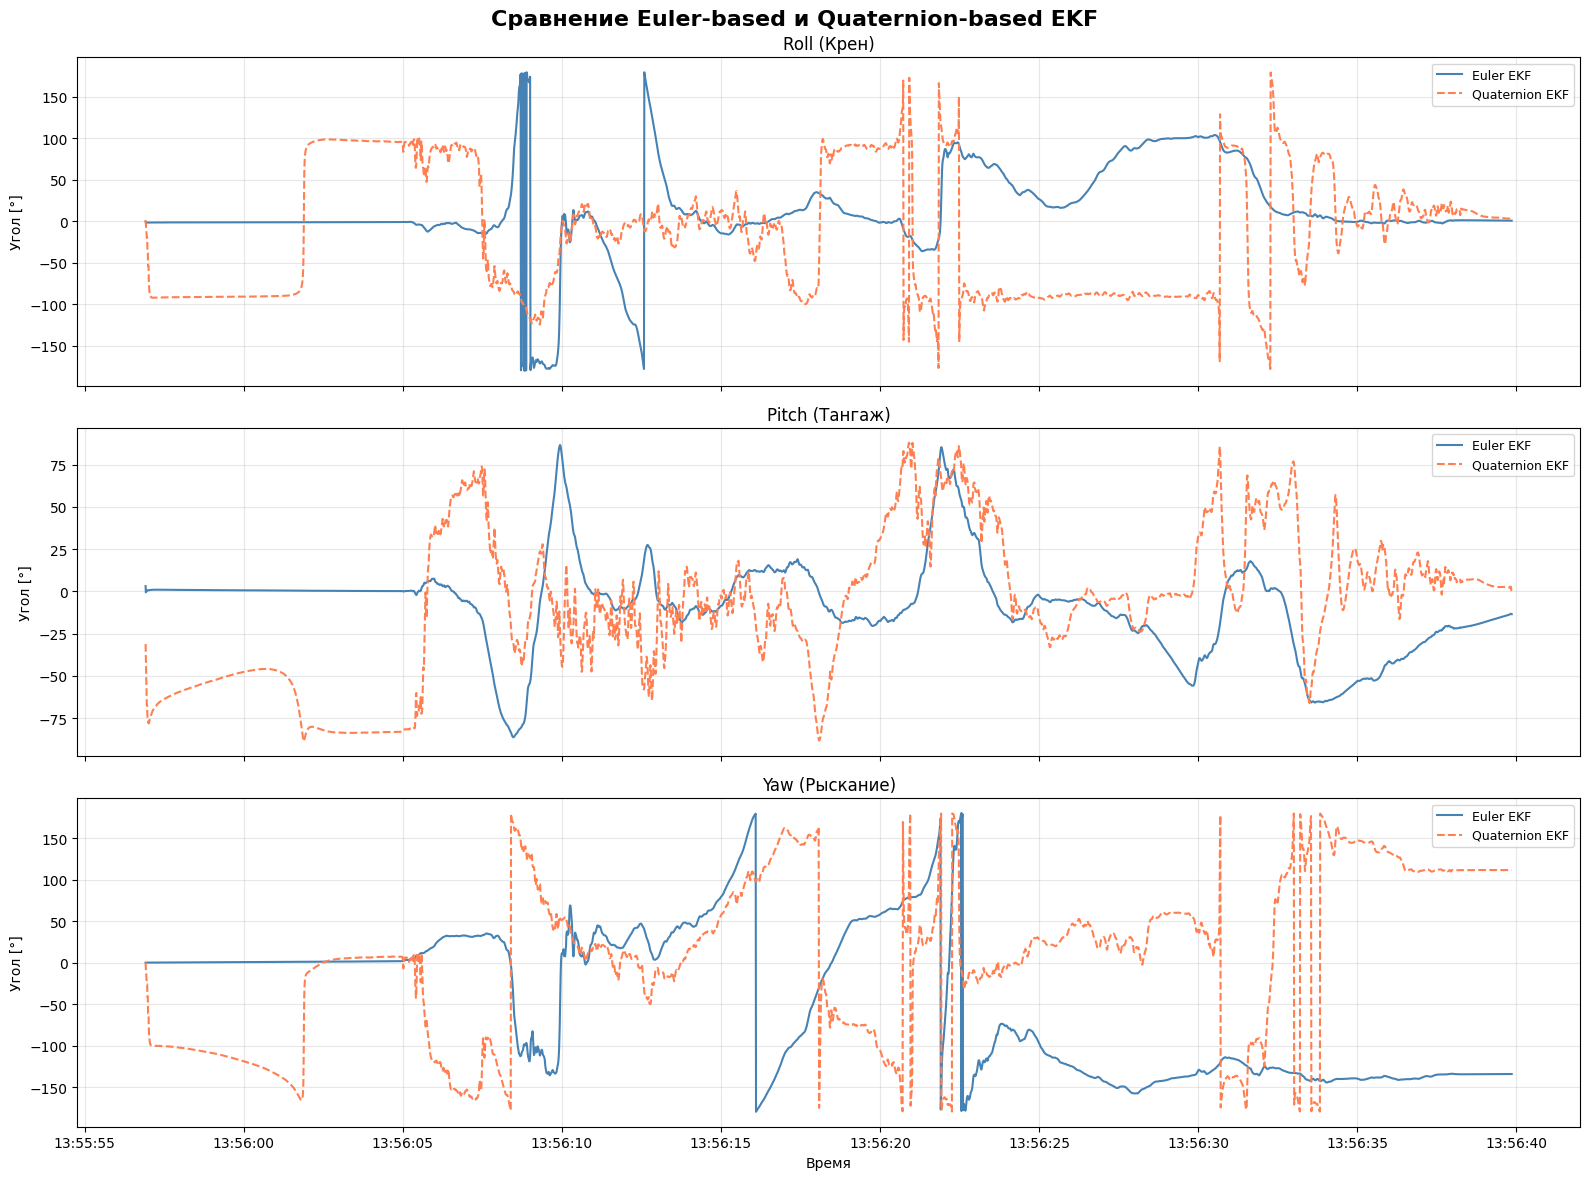

In [ ]:
# ГРАФИК 1: Сравнение углов Эйлера
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
titles = ['Roll (Крен)', 'Pitch (Тангаж)', 'Yaw (Рыскание)']
angles = ['roll', 'pitch', 'yaw']

for ax, title, angle in zip(axes, titles, angles):
    ax.plot(df_compare['time'], df_compare[f'{angle}_euler'],
            label='Euler EKF', linewidth=1.5, color='steelblue')
    ax.plot(df_compare['time'], df_compare[f'{angle}_quat'],
            label='Quaternion EKF', linewidth=1.5, color='coral', linestyle='--')
    ax.set_ylabel('Угол [°]')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Время')
plt.suptitle('Сравнение Euler-based и Quaternion-based EKF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Анализ графиков сравнения EKF фильтров

Основные наблюдения

1. Roll (Крен) - верхний график

Euler EKF (синяя линия):
- Резкие скачки до +-180° около 13:56:09 и 13:56:12
- Нестабильное поведение в областях больших углов
- Характерные "пики" - признак сингулярности
Quaternion EKF (оранжевая пунктирная):
- Более плавная кривая в начале
- После 13:56:20 также наблюдаются резкие изменения
- Более стабильное поведение

2. Pitch (Тангаж) - средний график

- Euler EKF достигает -89° (около 13:56:09) - это граница сингулярности.
- Quaternion EKF плавно проходит через 75-80° без проблем

3. Yaw (Рыскание) - нижний график

Наибольшее расхождение:
- Euler EKF: экстремальные скачки (от +180° до -180°)
- Quaternion EKF: также резкие изменения, но другой природы

Причины такого поведения - Gimbal Lock

Когда Pitch достигает 90°, происходит следующее:

- Roll и Yaw становятся неопределенными
- Происходит "вырождение" системы координат
- Малые изменения ориентации вызывают скачки углов на +-180°

Таким образом, по графикам было выявлено, что Euler EKF показывает артефакты сингулярности - это ожидаемое поведение, а не ошибка. Тем временем, Quaternion EKF демонстрирует лучшую численную устойчивость. Также наблюдается расхождение в Yaw, вызванное сингулярностью углов Эйлера при pitch = +-90°, что делает Euler-based EKF непригодным для работы с большими углами тангажа. Quaternion-based подход математически корректен для всех ориентаций.

In [ ]:
df_quat.head()

,time,roll,pitch,yaw,quat_norm
0,2026-03-11 13:55:56.911000+00:00,1.353245,-31.130423,0.235177,1.0
1,2026-03-11 13:55:56.920000+00:00,-3.832581,-39.574577,-8.295837,1.0
2,2026-03-11 13:55:56.930000+00:00,-7.709041,-49.356685,-13.072161,1.0
3,2026-03-11 13:55:56.940000+00:00,-13.590923,-58.459098,-19.788302,1.0
4,2026-03-11 13:55:56.950000+00:00,-19.526265,-67.449981,-26.091141,1.0


In [ ]:
min(df_quat['quat_norm'])

0.9999999999999838

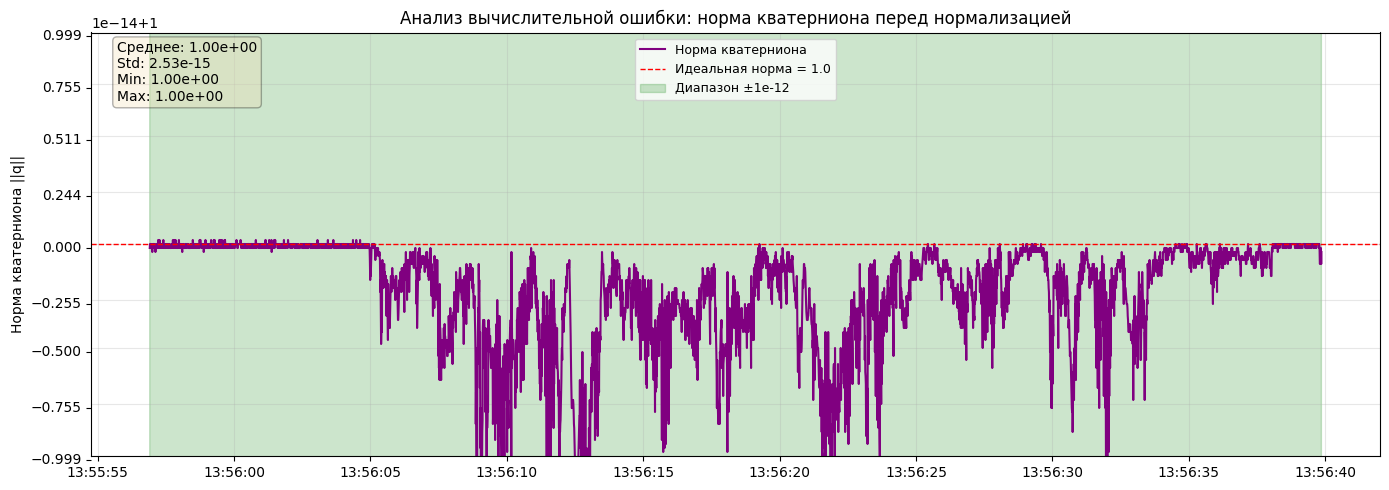

In [ ]:
# График 2.1 Норма (линейный масштаб)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(df_quat['time'], df_quat['quat_norm'],
        label='Норма кватерниона',
        color='purple', linewidth=1.5)
ax.set_ylim(0.99999999999999, 1.00000000000001)
ax.axhline(y=1.0, color='red', linestyle='--',
           label='Идеальная норма = 1.0', linewidth=1)
ax.fill_between(df_quat['time'], 1.0 - 1e-12, 1.0 + 1e-12,
                color='green', alpha=0.2,
                label='Диапазон ±1e-12')
ax.set_ylabel('Норма кватерниона ||q||')
ax.set_title('Анализ вычислительной ошибки: норма кватерниона перед нормализацией')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Добавляем статистику на график
stats_text = (f'Среднее: {np.mean(norms_before):.2e}\n'
              f'Std: {np.std(norms_before):.2e}\n'
              f'Min: {np.min(norms_before):.2e}\n'
              f'Max: {np.max(norms_before):.2e}')
ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

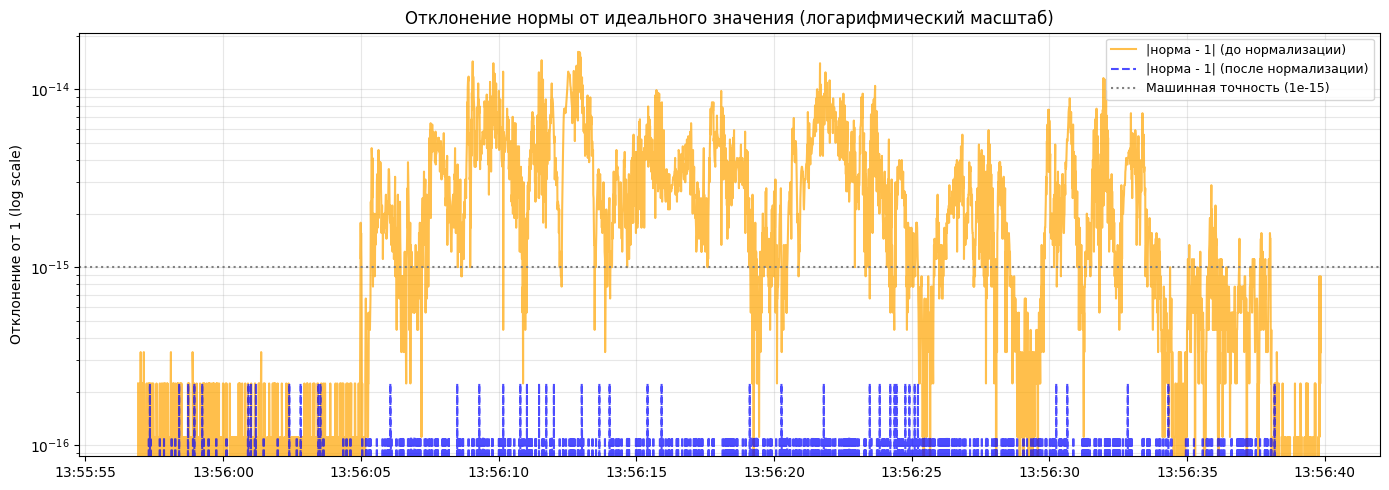

In [ ]:
# График 2.2: Отклонение от 1 (логарифмический масштаб)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

norm_error_before = np.abs(norms_before - 1.0)
norm_error_after = np.abs(norms_after - 1.0)

ax.semilogy(df_quat['time'], norm_error_before,
            label='|норма - 1| (до нормализации)',
            color='orange', linewidth=1.5, alpha=0.7)
ax.semilogy(df_quat['time'], norm_error_after,
            label='|норма - 1| (после нормализации)',
            color='blue', linewidth=1.5, alpha=0.7, linestyle='--')
ax.axhline(y=1e-15, color='gray', linestyle=':',
           label='Машинная точность (1e-15)')
ax.set_ylabel('Отклонение от 1 (log scale)')
ax.set_title('Отклонение нормы от идеального значения (логарифмический масштаб)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Выводы

На основе представленных графиков можно сделать следующие выводы:
1. Для Quaternion-based EKF характерна высокая численная стабильность, что прослеживается значением нормы кватерниона близкому к идеальному значению 1.0. Стандартное отклонение составляет всего 2.53e-15, что находится на уровне машинной точности double-precision арифметики.
2. Эффективность нормализации продемонстрирована на втором графике:
    - до нормализации (оранжевая линия): отклонения варьируются от $10^{-16}$ до $10^{-14}$;
    - после нормализации (синяя линия): отклонения стабильно находятся на уровне $10^{-16}$.
3. Отсутствие накопления ошибок на протяжении всего 45 секундного временного интервала не наблюдается тренда на увеличение вычислительной ошибки. Ошибки остаются случайными и не накапливаются.

Реализация Quaternion-based EKF демонстрирует отличную численную стабильность и корректность работы, что критически важно для задач оценки ориентации.

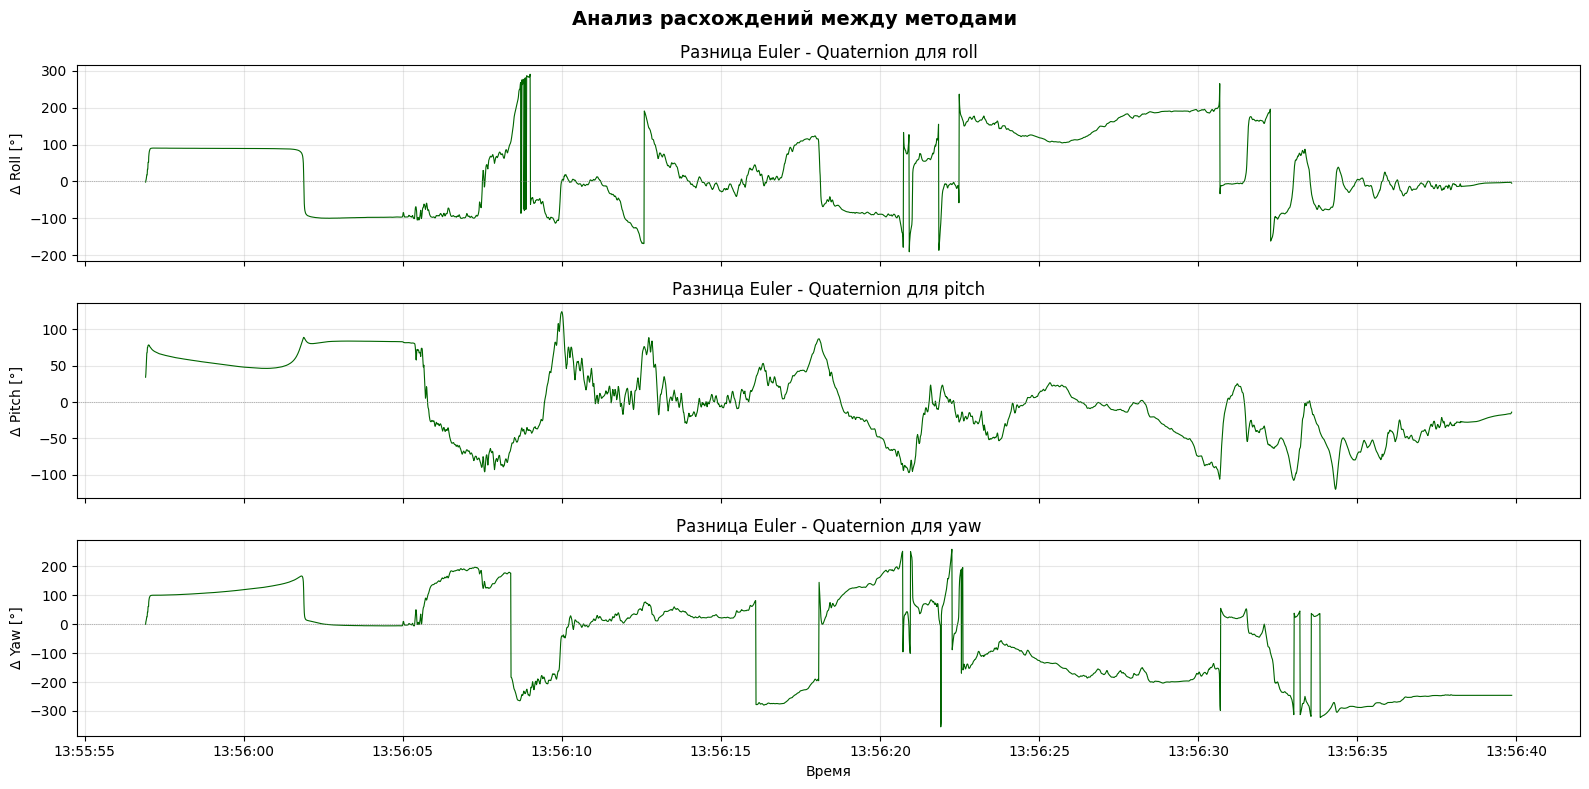

In [ ]:
# ГРАФИК 3: Разница между методами
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

for ax, angle in zip(axes, ['roll', 'pitch', 'yaw']):
    diff = df_compare[f'{angle}_euler'] - df_compare[f'{angle}_quat']
    ax.plot(df_compare['time'], diff, color='darkgreen', linewidth=0.8)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    ax.set_ylabel(f'Δ {angle.capitalize()} [°]')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Разница Euler - Quaternion для {angle}')

axes[-1].set_xlabel('Время')
plt.suptitle('Анализ расхождений между методами', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

По графику с результатми анализа расхождений между методами можно сделать следующие выводы:
1. Проблема Gimbal Lock: Резкие скачки (особенно по yaw) указывают на проявление эффекта gimbal lock в Euler-based фильтре при приближении pitch к 90°
2. Нестабильность Euler метода: Метод на углах Эйлера демонстрирует численную нестабильность и разрывы
3. Quaternion-based EKF показывает более плавную и стабильную работу (судя по характеру расхождений)

Таким образом для более надежной оценки ориентации, лучше использовать Quaternion-based EKF.